In [103]:
# Author: Sarbajit Mazumdar, Doctoral Researcher, Julius-Maximilians-Universität Würzburg
# Email:sarbajit.mazumdar@uni-wuerzburg.de
# 'Electronic spectrum of twisted bilayer graphene', A. O. Sboychakov, A. L. Rakhmanov, A. V. Rozhkov and Franco Nori
# Paper link: https://journals.aps.org/prb/abstract/10.1103/PhysRevB.92.075402

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from moirepy import BilayerMoireLattice, Layer

In [104]:
A_GRAPHENE = 2.46
D_SPACING = 3.35
ALPHA = (6.715, 0.762, 0.179, 1.411)
BETA = (6.811, 0.01, 19.176)
C_SCALE = 1.44
T_INTRA = 2.57

# Define the graphene layer
class Graphene(Layer):
    def __init__(self, pbc=False, study_proximity: int=1) -> None:
        lv1 = np.array([1, 0]) * A_GRAPHENE
        lv2 = np.array([0.5, np.sqrt(3) / 2]) * A_GRAPHENE

        basis_points = [
            (0, 0, "A"),
            (A_GRAPHENE, A_GRAPHENE / np.sqrt(3), "B"),
        ]

        # Standard neighbours for hexagonal lattice
        neigh_deltas = np.array([
            [0, 1/np.sqrt(3)],
            [-0.5, -1/(2 * np.sqrt(3))],
            [0.5, -1/(2 * np.sqrt(3))]
        ]) * A_GRAPHENE
        
        neighbours = {"A": neigh_deltas, "B": -neigh_deltas}
        super().__init__(lv1, lv2, basis_points, neighbours, pbc, study_proximity)

In [105]:
ll1, ll2, ul1, ul2 = 1, 2, 2, 1
# ll1, ll2, ul1, ul2 = 7, 8, 8, 7
# ll1, ll2, ul1, ul2 = 17, 18, 18, 17

lattice = BilayerMoireLattice(
    Graphene, ll1, ll2, ul1, ul2,
    n1=1, n2=1, pbc=True,
    translate_upper=(-A_GRAPHENE, -A_GRAPHENE / np.sqrt(3)),
)

# changing this changes the gap size... somehow
lattice.generate_connections(inter_layer_radius=A_GRAPHENE/ (2*3**0.5))
# lattice.generate_connections(inter_layer_radius=A_GRAPHENE)

twist angle = 0.3803 rad (21.7868 deg)
14 cells in upper lattice
14 cells in lower lattice


In [106]:
def screening_S(pos_i, pos_j, all_pos):
    rij = np.linalg.norm(pos_i - pos_j)
    ril = np.linalg.norm(all_pos - pos_i, axis=1)
    rjl = np.linalg.norm(all_pos - pos_j, axis=1)
    m = (ril > 1e-6) & (rjl > 1e-6)  # mask to remove l=i,j
    x = ((ril[m] + rjl[m]) / rij).sum()
    xi = BETA[0] * np.exp(-BETA[1] * x**BETA[2])
    return np.tanh(xi)

def v_sigma(rij):
    r_scaled = C_SCALE * rij
    return ALPHA[0] * r_scaled**(-ALPHA[1]) * np.exp(-ALPHA[2] * r_scaled**ALPHA[3])

def t_perp_func(pos_u, pos_l, all_pos, d):
    rij = np.linalg.norm(pos_u - pos_l)
    inplane = np.linalg.norm(pos_u[:2] - pos_l[:2])
    cos_a = d / np.sqrt(d**2 + inplane**2)
    S = screening_S(pos_u, pos_l, all_pos)
    return (cos_a**2) * v_sigma(rij) * (1.0 - S)

def tul(pos_u, pos_l, R, type_u, type_l, lattice, d):
    lower_3d = np.column_stack([lattice.lower_lattice.bigger_points, np.zeros(len(lattice.lower_lattice.bigger_points))])
    upper_3d = np.column_stack([lattice.upper_lattice.bigger_points, np.full(len(lattice.upper_lattice.bigger_points), d)])
    all_pos = np.vstack([lower_3d, upper_3d])

    res = [t_perp_func(np.append(pu, d), np.append(pl, 0.0), all_pos, d) for pu, pl in zip(pos_u, pos_l+R)]
    return np.array(res)

def tlu(pos_l, pos_u, R, type_l, type_u, lattice, d):
    return np.conj(tul(pos_u, pos_l, R, type_u, type_l, lattice, d))

In [107]:
def reciprocal_vectors(v1, v2):
    matrix = np.column_stack([v1, v2])
    inv_t = 2.0 * np.pi * np.linalg.inv(matrix).T
    return inv_t[:, 0], inv_t[:, 1]

g1, g2 = reciprocal_vectors(lattice.mlv1, lattice.mlv2)
gamma_point = np.zeros(2)
k1_point, k2_point = (g1 + 2 * g2) / 3.0, (2 * g1 + g2) / 3.0

def get_kpath(nseg):
    """Generates the High-Symmetry path Gamma -> K1 -> K2 -> Gamma."""
    path_pts = [gamma_point, k1_point, k2_point, gamma_point]
    labels = [r"$\Gamma$", r"$K_1$", r"$K_2$", r"$\Gamma$"]

    k_list, x_coords = [], []
    ticks, tick_labels = [0.0], [labels[0]]
    current_x = 0.0

    for i in range(len(path_pts) - 1):
        is_last = (i == len(path_pts) - 2)
        n_pts = nseg + 1 if is_last else nseg
        t = np.linspace(0, 1, n_pts, endpoint=is_last)

        segment = (1 - t)[:, None] * path_pts[i] + t[:, None] * path_pts[i+1]
        k_list.extend(segment)
        x_coords.append(current_x + t)

        current_x = x_coords[-1][-1] + (0 if is_last else 1/nseg)
        ticks.append(x_coords[-1][-1] if is_last else current_x - 1/nseg)
        tick_labels.append(labels[i+1])

    return np.array(k_list), np.concatenate(x_coords), ticks, tick_labels

k_points, x_ax, ticks, labels = get_kpath(100)

In [108]:
ham_real_space = lattice.generate_hamiltonian(
    tll=-T_INTRA, tuu=-T_INTRA,
    tul=tul, tlu=tlu,
    extra_inputs={"d": D_SPACING},
).toarray()

all_energies = []
for k in tqdm(k_points):
    phase = lattice.get_phase(k).toarray()
    ham_k = ham_real_space * phase
    eigvals = np.linalg.eigvalsh(ham_k)
    all_energies.append(eigvals)

all_energies = np.array(all_energies)

100%|██████████| 301/301 [00:00<00:00, 12620.94it/s]


In [109]:
mid_idx = all_energies.shape[1] // 2
lower_band = all_energies[:, mid_idx - 1]
upper_band = all_energies[:, mid_idx]

# Calculate the shift (mu) to center the gap at 0
v_top = np.max(lower_band)
c_bottom = np.min(upper_band)
mu_shift = (v_top + c_bottom) / 2

# Apply the vertical shift
all_energies_shifted = all_energies - mu_shift

# Calculate and print gap information
gap = c_bottom - v_top

print(f"Chemical Potential Shift (mu): {mu_shift*1e3:.2f} meV")
print(f"Calculated Band Gap: {gap*1e3:.2f} meV")

Chemical Potential Shift (mu): 0.13 meV
Calculated Band Gap: 108.73 meV


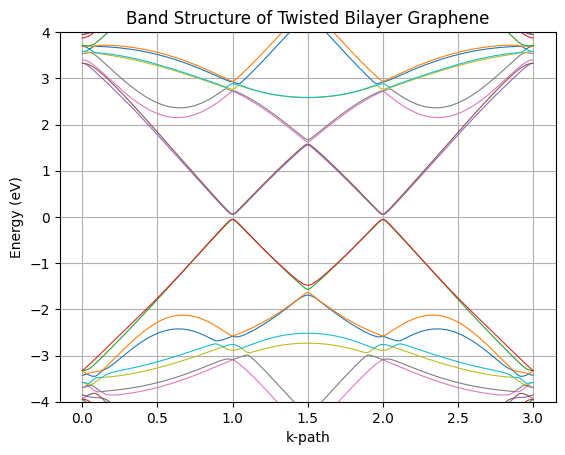

In [ ]:
plt.plot(x_ax, np.array(all_energies_shifted), lw=0.8)
plt.xticks(ticks, labels)
plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.ylim(-4, 4)
plt.title("Band Structure of Twisted Bilayer Graphene")
plt.grid()